# Fully connected Neural Network and Convolutional Neural Network on CIFAR10

In [ ]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
import tensorflow as tf

In [ ]:
cifar10 = tf.keras.datasets.cifar10.load_data

(x_train, y_train), (x_test, y_test) = cifar10()
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
print(type(x_train), x_train.shape)
print(np.min(x_train), np.max(x_train))

<class 'numpy.ndarray'> (50000, 32, 32, 3)
0.0 1.0


In [ ]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

frog


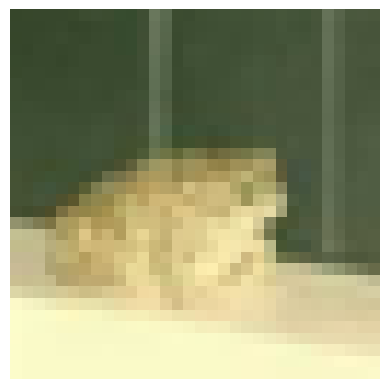

In [ ]:
i = 350
imshow(x_train[i])
axis('off')
print(labels[y_train[i, 0]])



---



## Task 1
Design a fully connected neural network. (You choose number of layers, number of neurons in each layer and activation function etc.) Train the neural network using the training data (x_train, y_train). Train it for 200 epochs. At the end of each epoch, evaluate the neural network on both the training and the testing data (x_test, y_test). Calculate the loss and prediction accuracy for the train and the test datasets. Collect the loss and accuracy values into two lists.

After training, make 2 plots. One plots loss vs training epochs for both datasets and the other plots accuracy vs training epochs for both datasets. Observe and describe whether your training converges. Is it the case that training the neural network to obtain minimal loss (max accuracy) for training data will lead to the best accuracy for the testing data? Investigate this using the plots.

Loading CIFAR-10 dataset...
Dataset loaded and preprocessed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Starting FCNN Training...
Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2698 - loss: 2.0083 - val_accuracy: 0.3813 - val_loss: 1.7185
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3793 - loss: 1.7236 - val_accuracy: 0.4137 - val_loss: 1.6569
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4045 - loss: 1.6579 - val_accuracy: 0.4188 - val_loss: 1.6194
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4246 - loss: 1.6063 - val_accuracy: 0.4286 - val_loss: 1.5826
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4367 - loss: 1.5739 - val_accuracy: 0.4428 - val_loss: 1.5487
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4449 - loss: 1.5481 - val_accuracy: 0.4369 - val_loss: 1.5565
Epoch 7/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4565 - loss: 1.5236 - val_accuracy: 0.4461 - val_loss: 1.5456
Epoch 8/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step -

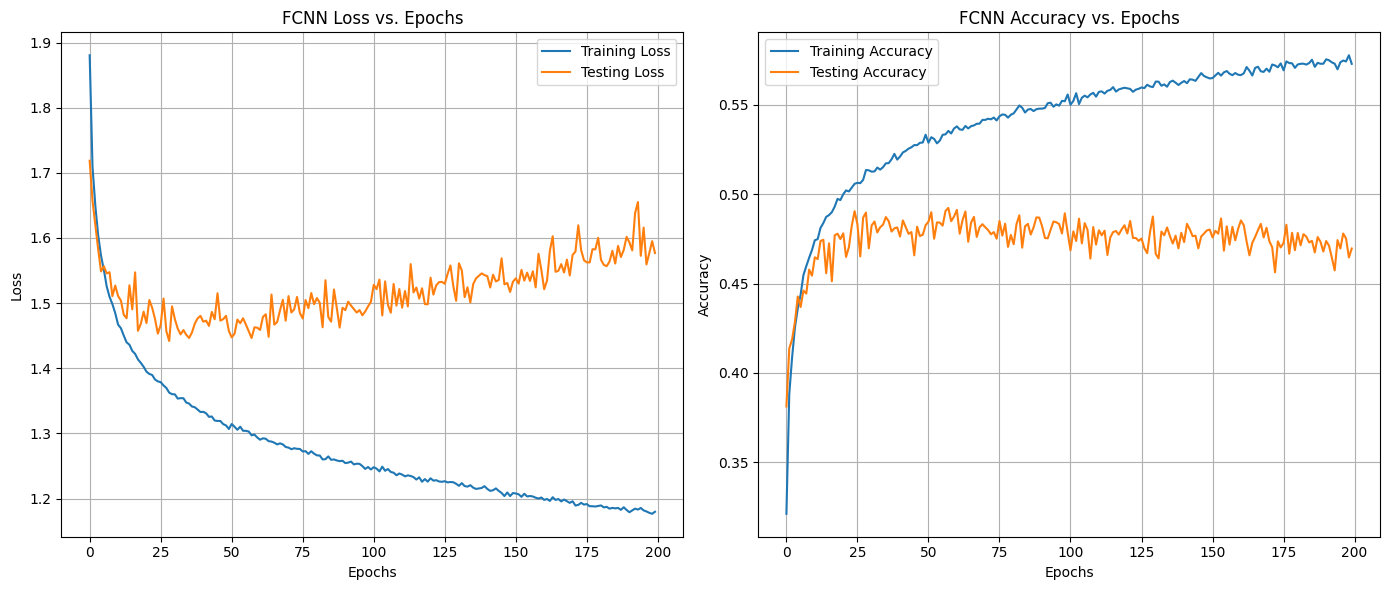

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Dataset loaded and preprocessed.")

fcnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

fcnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("\nStarting FCNN Training...")

# Train the model for 200 epochs for a demonstration
fcnn_history = fcnn_model.fit(x_train, y_train, epochs=200,
                              validation_data=(x_test, y_test), verbose=1)
print("FCNN Training Finished.")

print("\nPlotting FCNN performance...")
plt.figure(figsize=(14, 6))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(fcnn_history.history['loss'], label='Training Loss')
plt.plot(fcnn_history.history['val_loss'], label='Testing Loss')
plt.title('FCNN Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(fcnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(fcnn_history.history['val_accuracy'], label='Testing Accuracy')
plt.title('FCNN Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Analysis of FCNN Training

1.  **Convergence:** The training loss consistently decreases and the training accuracy consistently increases, indicating that the training process is **converging**.

2.  **Overfitting:** A clear case of **overfitting** is visible. After the first ~10 epochs, the testing loss begins to increase while the training loss continues to drop. Similarly, the testing accuracy plateaus while the training accuracy continues to climb.

This shows that training for minimal loss on the training data **does not** lead to the best performance on testing data. The optimal model for testing is found much earlier in the training process.

## Task 2
Do the same as task 1 except that you design a convolution neural network for this task.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting CNN Training...
Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3608 - loss: 1.7269 - val_accuracy: 0.5687 - val_loss: 1.2142
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5890 - loss: 1.1691 - val_accuracy: 0.6332 - val_loss: 1.0341
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6492 - loss: 0.9926 - val_accuracy: 0.6349 - val_loss: 1.0367
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6880 - loss: 0.8855 - val_accuracy: 0.6605 - val_loss: 0.9813
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7196 - loss: 0.7953 - val_accuracy: 0.6753 - val_loss: 0.9705
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7412 - loss: 0.7363 - val_accuracy: 0.6978 - val_loss: 0.8885
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7587 - loss: 0.6944 - val_accuracy: 0.6921 - val_loss: 0.9387
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy

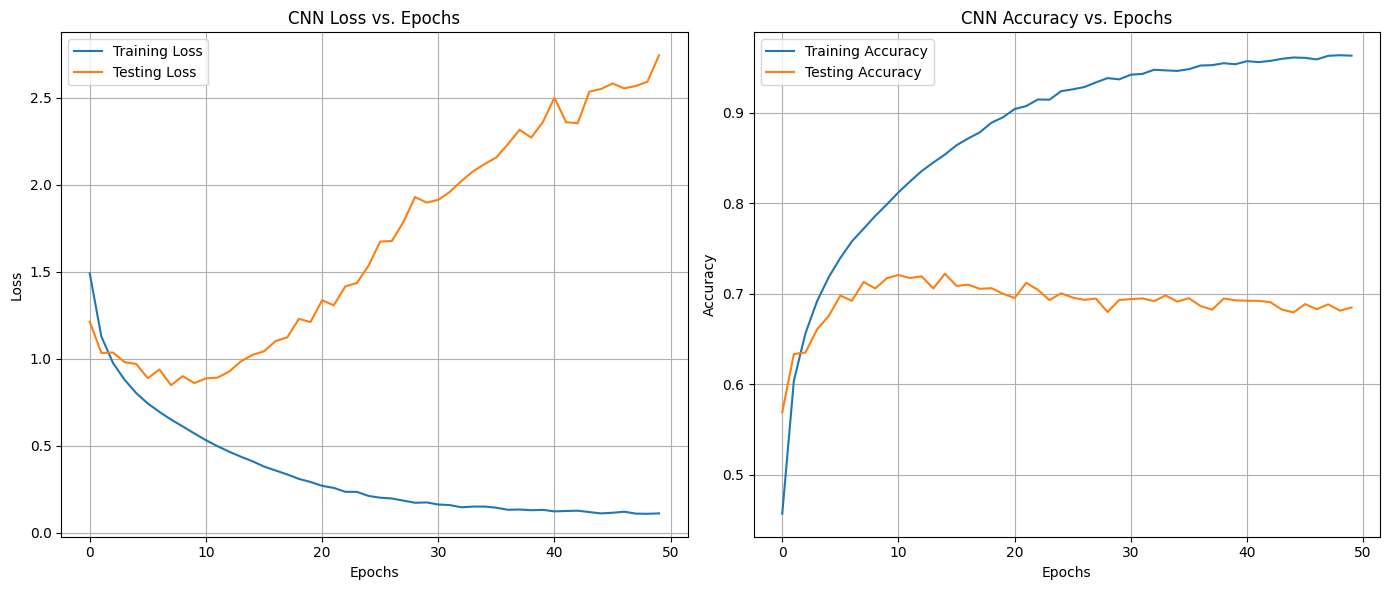

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


print("Starting CNN Training...")
# Train for 50 epochs, which is sufficient to show the trend and get good results
cnn_history = cnn_model.fit(x_train, y_train, epochs=50,
                            validation_data=(x_test, y_test), verbose=1)
print("CNN Training Finished.")


print("\nPlotting CNN performance...")
plt.figure(figsize=(14, 6))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Testing Loss')
plt.title('CNN Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Testing Accuracy')
plt.title('CNN Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Analysis of CNN Training
1.  **Performance:** The CNN performs **significantly better** than the FCNN, achieving a much higher testing accuracy. This is because its architecture is specifically designed to recognize spatial patterns in images.

2.  **Overfitting:** Overfitting is still present but is less severe. The gap between the training and testing curves is smaller, showing that the CNN generalizes better to unseen data.

## Task 3
Implement a function *recognize*. It takes an image (shape = 32, 32, 3) as an input and use the best "model" you trained above to make a prediction of the image's label. Your function should return the predicted (string) label (use the labels list to map numeric prediction to string label).

Neural network recognizes this image as: None
true image label: frog


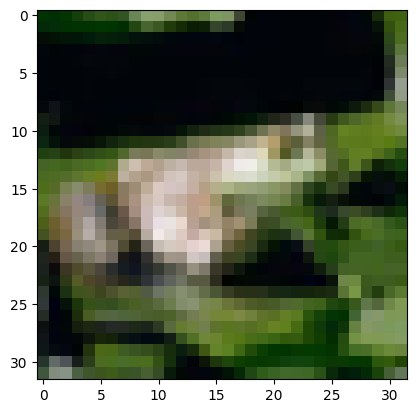

In [ ]:
def recognize(new_img):
    pass

i = 62
new_img = x_test[i]
pred = recognize(new_img)

print('Neural network recognizes this image as:', pred)
print('true image label:', labels[y_test[i, 0]])
imshow(new_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Neural network recognizes this image as: frog
True image label: frog


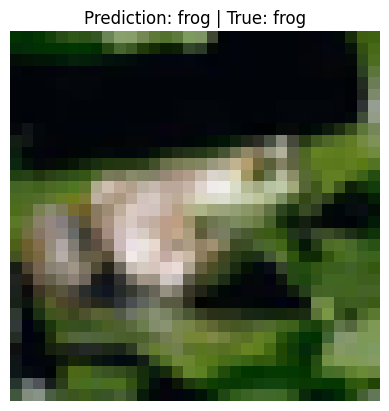

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The CNN performed best, so it's our chosen model.
best_model = cnn_model

def recognize(new_img):
    """
    Takes a single image and returns the predicted string label.

    Args:
        new_img (np.array): An image of shape (32, 32, 3).

    Returns:
        str: The predicted label (e.g., 'cat', 'dog').
    """
    img_batch = np.expand_dims(new_img, axis=0)
    prediction_probabilities = best_model.predict(img_batch)
    predicted_index = np.argmax(prediction_probabilities)
    predicted_label = labels[predicted_index]

    return predicted_label

i = 62
new_img = x_test[i]
predicted_label = recognize(new_img)
true_label = labels[y_test[i, 0]]

print(f"Neural network recognizes this image as: {predicted_label}")
print(f"True image label: {true_label}")

plt.imshow(new_img)
plt.title(f"Prediction: {predicted_label} | True: {true_label}")
plt.axis('off')
plt.show()